# Fabric Defect Classification — 01. Baseline CNN

## 1. Imports & setup

In [17]:
import os
import copy
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_recall_fscore_support, roc_curve, auc
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

Using device: cuda


## 2. Load the pre-split dataset & augmentation

In [18]:
DATA_DIR = 'fabric_split'
IMG_SIZE = 128
BATCH    = 32

# ImageNet stats — used because the network is small enough that ImageNet's distributional
# normalisation is a reasonable default and matches what the Improved and Tuned notebooks use.
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]),
}

image_datasets = {
    s: datasets.ImageFolder(os.path.join(DATA_DIR, s), data_transforms[s])
    for s in ['train', 'val', 'test']
}
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH, shuffle=True,  num_workers=0),
    'val':   DataLoader(image_datasets['val'],   batch_size=BATCH, shuffle=False, num_workers=0),
    'test':  DataLoader(image_datasets['test'],  batch_size=BATCH, shuffle=False, num_workers=0),
}

dataset_sizes = {s: len(image_datasets[s]) for s in ['train', 'val', 'test']}
class_names   = image_datasets['train'].classes
num_classes   = len(class_names)

print('Classes      :', class_names)
print('Dataset sizes:', dataset_sizes)

Classes      : ['hole', 'horizontal', 'stain', 'vertical']
Dataset sizes: {'train': 640, 'val': 138, 'test': 138}


### 2.1 Visualise an augmented training batch

Useful for the report — it shows exactly what the network sees after augmentation.

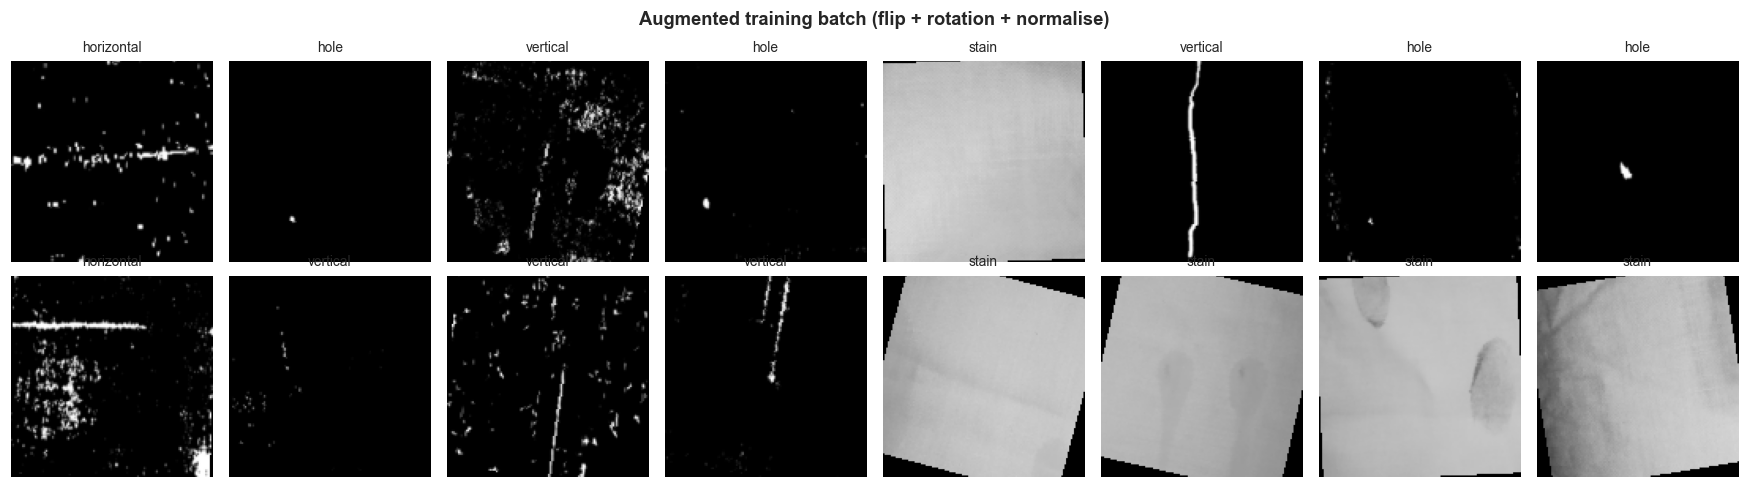

In [19]:
def denormalise(t):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

batch_imgs, batch_labels = next(iter(dataloaders['train']))
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for ax, img, lbl in zip(axes.flatten(), batch_imgs[:16], batch_labels[:16]):
    ax.imshow(denormalise(img).permute(1, 2, 0).numpy())
    ax.set_title(class_names[lbl.item()], fontsize=9)
    ax.axis('off')
plt.suptitle('Augmented training batch (flip + rotation + normalise)', fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_augmented_batch.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Class-imbalance weights


In [20]:
train_labels = [label for _, label in image_datasets['train'].samples]
class_counts = Counter(train_labels)
total        = sum(class_counts.values())

class_weights = [total / (num_classes * class_counts[i]) for i in range(num_classes)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print('Training-set class counts :', dict(zip(class_names, [class_counts[i] for i in range(num_classes)])))
print('Training-set class weights:', dict(zip(class_names, [round(w, 4) for w in class_weights])))

Training-set class counts : {'hole': 197, 'horizontal': 94, 'stain': 278, 'vertical': 71}
Training-set class weights: {'hole': 0.8122, 'horizontal': 1.7021, 'stain': 0.5755, 'vertical': 2.2535}


## 4. Baseline CNN architecture


In [21]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes: int = 4):
        super().__init__()
        # Input: 3 × 128 × 128
        self.conv1 = nn.Conv2d(3,   32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)               # 32 × 64 × 64
        self.conv2 = nn.Conv2d(32,  64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)               # 64 × 32 × 32
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)               # 128 × 16 × 16

        self.fc1     = nn.Linear(128 * 16 * 16, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = x.flatten(1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model = BaselineCNN(num_classes=num_classes).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
print(model)

Trainable parameters: 16,873,028
BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=4, bias=True)
)


## 5. Training loop

In [23]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 15

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc = 0.0
best_wts = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 24)

    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss     += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc  = (running_corrects.float() / dataset_sizes[phase]).item()
        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)
        print(f'  {phase:<5s} loss={epoch_loss:.4f}  acc={epoch_acc:.4f}')

        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_wts = copy.deepcopy(model.state_dict())

print(f'\nTraining complete. Best val acc = {best_acc:.4f}')
model.load_state_dict(best_wts)
torch.save(best_wts, 'baseline_cnn_weights.pth')
with open('baseline_history.json', 'w') as f:
    json.dump(history, f, indent=2)

Epoch 1/15
------------------------
  train loss=0.8267  acc=0.6875
  val   loss=0.7712  acc=0.7464
Epoch 2/15
------------------------
  train loss=0.6984  acc=0.7438
  val   loss=0.6160  acc=0.8478
Epoch 3/15
------------------------
  train loss=0.6114  acc=0.8141
  val   loss=0.5619  acc=0.7754
Epoch 4/15
------------------------
  train loss=0.5770  acc=0.7937
  val   loss=0.5510  acc=0.8551
Epoch 5/15
------------------------
  train loss=0.4427  acc=0.8656
  val   loss=0.5246  acc=0.8406
Epoch 6/15
------------------------
  train loss=0.4467  acc=0.8703
  val   loss=0.5170  acc=0.8696
Epoch 7/15
------------------------
  train loss=0.5380  acc=0.8688
  val   loss=0.4635  acc=0.9058
Epoch 8/15
------------------------
  train loss=0.4416  acc=0.8578
  val   loss=0.5087  acc=0.8551
Epoch 9/15
------------------------
  train loss=0.3497  acc=0.9000
  val   loss=0.3549  acc=0.8696
Epoch 10/15
------------------------
  train loss=0.3783  acc=0.9000
  val   loss=0.5592  acc=0.9058

## 6. Training-curve visualisations

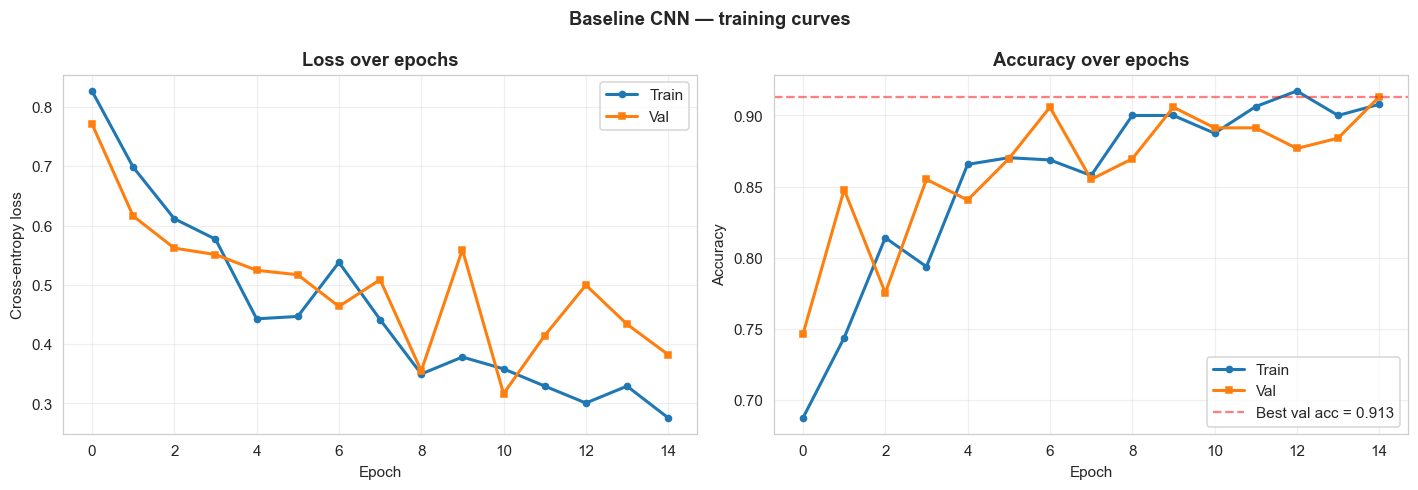

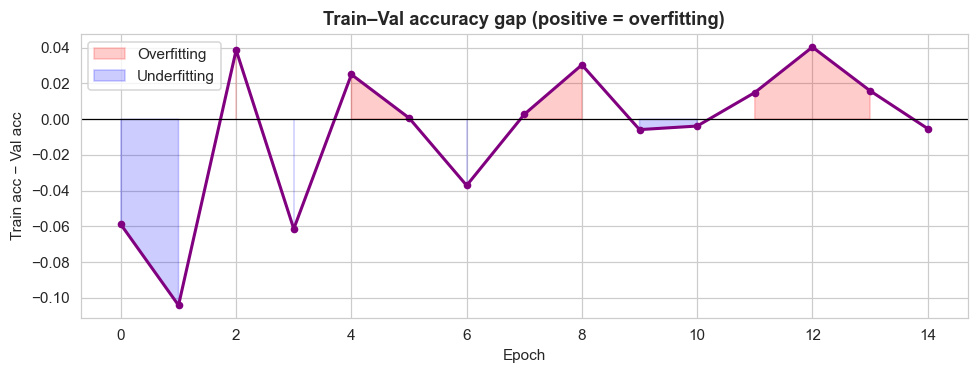

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history['train_loss'], '-o', label='Train', linewidth=2, markersize=4)
axes[0].plot(history['val_loss'],   '-s', label='Val',   linewidth=2, markersize=4)
axes[0].set_title('Loss over epochs', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], '-o', label='Train', linewidth=2, markersize=4)
axes[1].plot(history['val_acc'],   '-s', label='Val',   linewidth=2, markersize=4)
axes[1].axhline(best_acc, color='red', linestyle='--', alpha=0.5,
                label=f'Best val acc = {best_acc:.3f}')
axes[1].set_title('Accuracy over epochs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Baseline CNN — training curves', fontweight='bold')
plt.tight_layout()
plt.show()

# Diagnose train-val gap (overfitting indicator)
gap = np.array(history['train_acc']) - np.array(history['val_acc'])
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(gap, '-o', color='purple', linewidth=2, markersize=4)
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(range(len(gap)), 0, gap, where=(gap > 0), alpha=0.2, color='red',  label='Overfitting')
ax.fill_between(range(len(gap)), 0, gap, where=(gap < 0), alpha=0.2, color='blue', label='Underfitting')
ax.set_title('Train–Val accuracy gap (positive = overfitting)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train acc − Val acc')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Test-set evaluation

First and only touch of the test set. Best-val weights are already loaded into `model`.

In [25]:
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs   = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true); y_pred = np.array(y_pred); y_prob = np.array(y_prob)
test_acc = (y_true == y_pred).mean()
print(f'Test accuracy: {test_acc:.4f}')
print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Test accuracy: 0.9130

Classification report:
              precision    recall  f1-score   support

        hole     0.8667    0.9286    0.8966        42
  horizontal     0.9333    0.6667    0.7778        21
       stain     1.0000    1.0000    1.0000        60
    vertical     0.7222    0.8667    0.7879        15

    accuracy                         0.9130       138
   macro avg     0.8806    0.8655    0.8656       138
weighted avg     0.9191    0.9130    0.9116       138



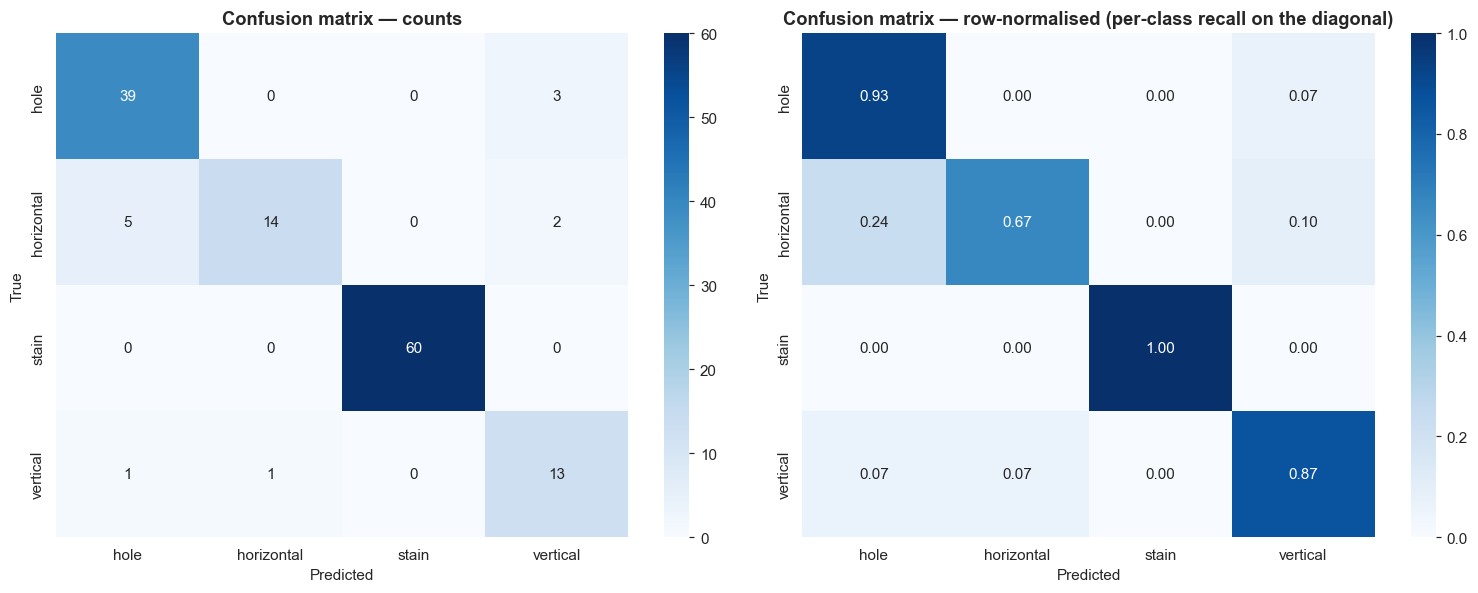

In [26]:
# Confusion matrix — raw counts and row-normalised
cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(cm,     annot=True, fmt='d',     cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion matrix — counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Confusion matrix — row-normalised (per-class recall on the diagonal)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

     class  precision  recall     f1  support
      hole     0.8667  0.9286 0.8966       42
horizontal     0.9333  0.6667 0.7778       21
     stain     1.0000  1.0000 1.0000       60
  vertical     0.7222  0.8667 0.7879       15


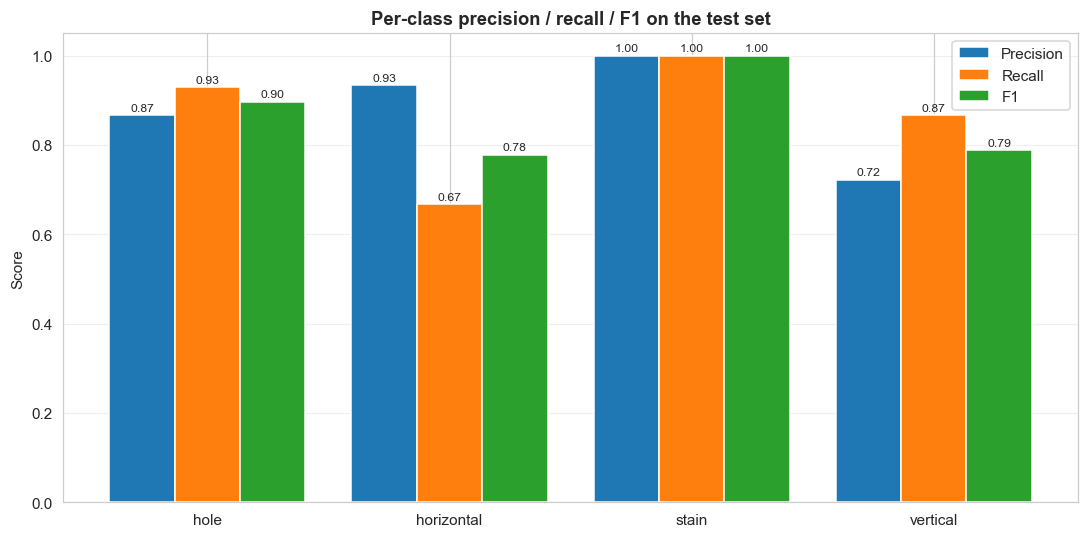

In [27]:
# Per-class precision / recall / F1 bar chart — a more readable view than the text report
p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=range(num_classes), zero_division=0)
metrics_df = pd.DataFrame({
    'class': class_names, 'precision': p, 'recall': r, 'f1': f1, 'support': sup
})
print(metrics_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(num_classes); w = 0.27
ax.bar(x - w, metrics_df['precision'], w, label='Precision', color='#1f77b4')
ax.bar(x,     metrics_df['recall'],    w, label='Recall',    color='#ff7f0e')
ax.bar(x + w, metrics_df['f1'],        w, label='F1',        color='#2ca02c')
ax.set_xticks(x); ax.set_xticklabels(class_names)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Per-class precision / recall / F1 on the test set', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for i in range(num_classes):
    ax.text(i - w, metrics_df['precision'][i] + 0.01, f'{metrics_df["precision"][i]:.2f}', ha='center', fontsize=8)
    ax.text(i,     metrics_df['recall'][i]    + 0.01, f'{metrics_df["recall"][i]:.2f}',    ha='center', fontsize=8)
    ax.text(i + w, metrics_df['f1'][i]        + 0.01, f'{metrics_df["f1"][i]:.2f}',        ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('baseline_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

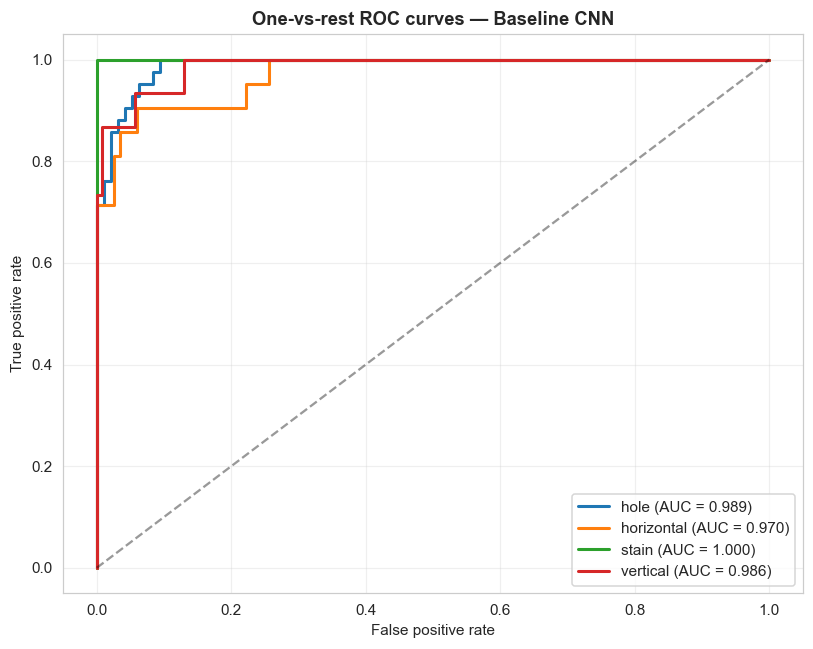

In [28]:
# One-vs-rest ROC curves — useful for the report's discussion of class separability
fig, ax = plt.subplots(figsize=(7.5, 6))
for i, cls in enumerate(class_names):
    y_bin = (y_true == i).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_prob[:, i])
    ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC = {auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('One-vs-rest ROC curves — Baseline CNN', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sample predictions — correct and incorrect


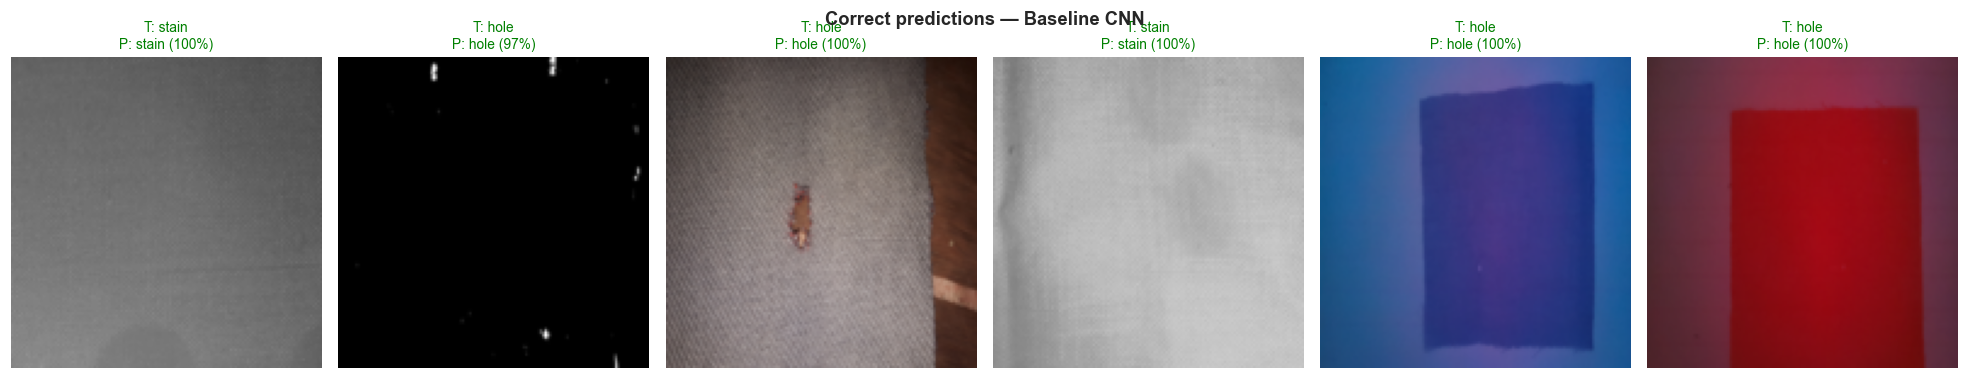

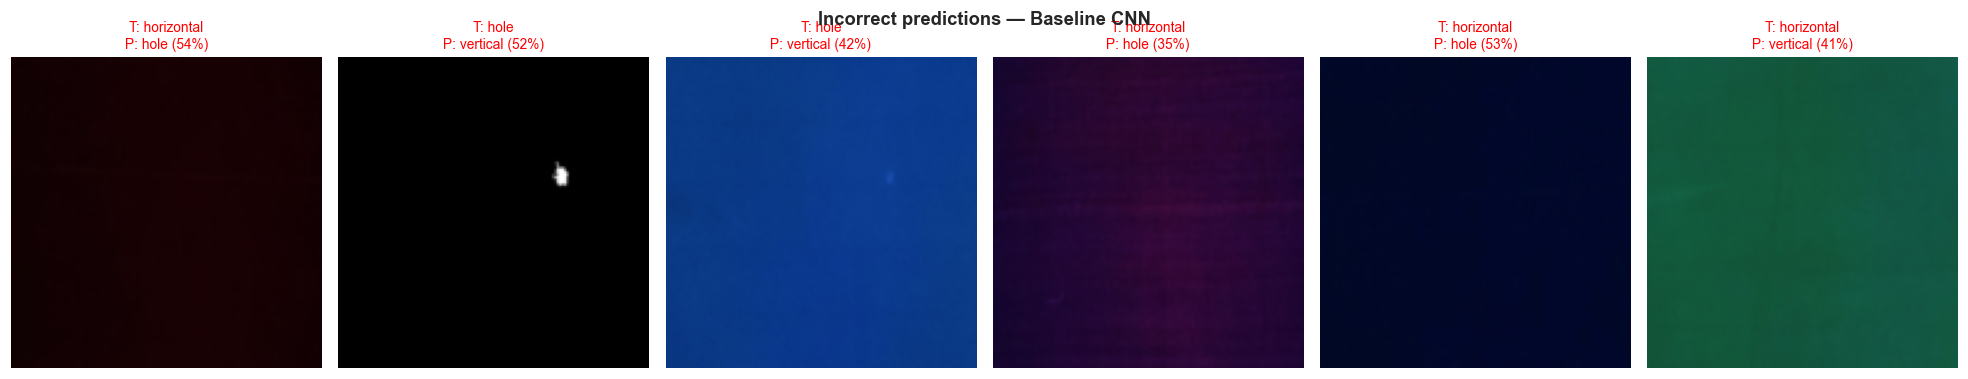

In [29]:
# Re-iterate over the test loader, this time collecting image tensors so we can visualise
all_imgs, all_true, all_pred, all_conf = [], [], [], []
model.eval()
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device); labels = labels.to(device)
        probs  = F.softmax(model(inputs), dim=1)
        conf, preds = torch.max(probs, dim=1)
        all_imgs.append(inputs.cpu())
        all_true.append(labels.cpu())
        all_pred.append(preds.cpu())
        all_conf.append(conf.cpu())
all_imgs = torch.cat(all_imgs); all_true = torch.cat(all_true)
all_pred = torch.cat(all_pred); all_conf = torch.cat(all_conf)

correct_idx = (all_pred == all_true).nonzero(as_tuple=True)[0].tolist()
wrong_idx   = (all_pred != all_true).nonzero(as_tuple=True)[0].tolist()
rng = random.Random(SEED)
correct_sample = rng.sample(correct_idx, min(6, len(correct_idx)))
wrong_sample   = rng.sample(wrong_idx,   min(6, len(wrong_idx))) if wrong_idx else []

def plot_grid(indices, title, save):
    if not indices:
        print(f'(no examples for: {title})'); return
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
    if n == 1: axes = [axes]
    for ax, i in zip(axes, indices):
        ax.imshow(denormalise(all_imgs[i]).permute(1, 2, 0).numpy())
        t, p, c = class_names[all_true[i]], class_names[all_pred[i]], all_conf[i].item()
        color = 'green' if t == p else 'red'
        ax.set_title(f'T: {t}\nP: {p} ({c*100:.0f}%)', color=color, fontsize=9)
        ax.axis('off')
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

plot_grid(correct_sample, 'Correct predictions — Baseline CNN',  'baseline_correct.png')
plot_grid(wrong_sample,   'Incorrect predictions — Baseline CNN','baseline_wrong.png')

## 9. Save metrics for cross-notebook comparison

In [30]:
baseline_metrics = {
    'model_name'    : 'Baseline CNN',
    'best_val_acc'  : float(best_acc),
    'test_acc'      : float(test_acc),
    'test_precision_macro': float(precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)[0]),
    'test_recall_macro'   : float(precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)[1]),
    'test_f1_macro'       : float(precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)[2]),
    'num_params'    : int(n_params),
    'num_epochs'    : NUM_EPOCHS,
    'class_names'   : class_names,
}
with open('baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=2)
print('Saved baseline_metrics.json')
print(json.dumps(baseline_metrics, indent=2))

Saved baseline_metrics.json
{
  "model_name": "Baseline CNN",
  "best_val_acc": 0.9130434989929199,
  "test_acc": 0.9130434782608695,
  "test_precision_macro": 0.8805555555555555,
  "test_recall_macro": 0.8654761904761905,
  "test_f1_macro": 0.8655520724486241,
  "num_params": 16873028,
  "num_epochs": 15,
  "class_names": [
    "hole",
    "horizontal",
    "stain",
    "vertical"
  ]
}


## 10. Single-image inference helper

In [31]:
def predict_single_image(image_path: str):
    model.eval()
    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f'Could not load {image_path}: {e}'); return
    x = data_transforms['val'](image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1)[0]
        conf, idx = torch.max(probs, 0)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(image); ax1.axis('off')
    ax1.set_title(f'Predicted: {class_names[idx]} ({conf*100:.1f}%)')
    ax2.barh(class_names, probs.cpu().numpy(), color='steelblue')
    ax2.set_xlim(0, 1); ax2.set_xlabel('Probability')
    ax2.set_title('Class probabilities')
    plt.tight_layout(); plt.show()

# Example usage — set a real path to test:
# predict_single_image('fabric_split/test/hole/some_image.jpg')